Questo esercizio calcola lo spettro di potenza P(k) a partire da un catalogo di cluster di galassie simulato (http://www.magneticum.org/data.html#). Dopo aver calcolato il campo di densità e il suo spettro in spazio di Fourier, si confronta il risultato numerico con quello teorico ottenuto da CAMB, tenendo conto del bias galattico.

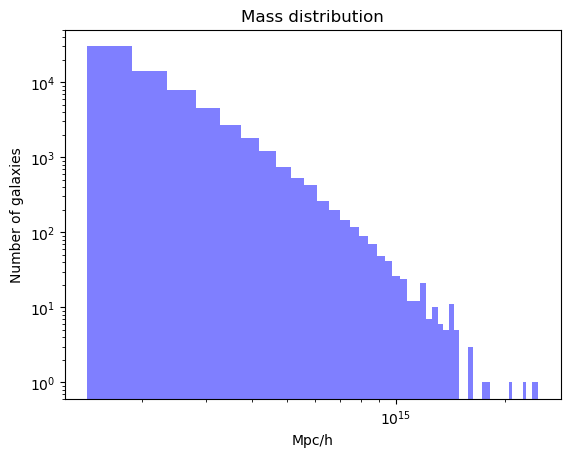

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfftn,fftfreq,rfftfreq  

L=2688  # Dimensione del box in Mpc/h
volume=L**3

# carico le coordinate x, y, z (divise per 1000 per avere unità in Mpc/h)
x,y,z=np.genfromtxt('cluster_Box0_z0.txt',usecols=(1,2,3),unpack=True)/1000  

# Carico la massa dei cluster
mass=np.genfromtxt('cluster_Box0_z0.txt',usecols=(7),unpack=True)
n_points=len(x) # Numero di oggetti
density=n_points/volume # Densità media

plt.hist(mass,bins=50,color='blue',alpha=0.5) # Istogramma della distribuzione delle masse
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mpc/h')
plt.ylabel('Number of galaxies')
plt.title('Mass distribution')
plt.show()

Cell size:  42.0
Mean density in the cell:  0.24880599975585938


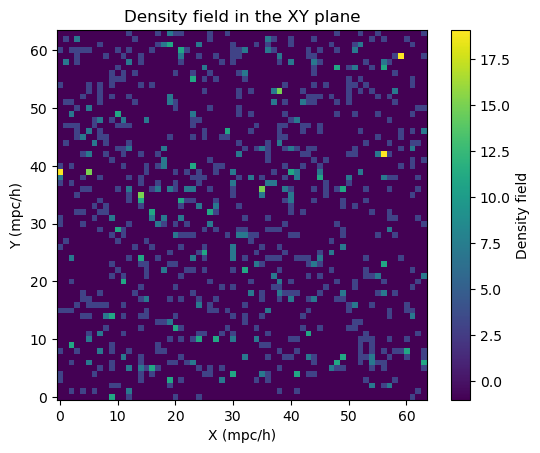

In [ ]:
n_cells=64  # Numero di celle lungo un asse
cell_size=L/n_cells  # Dimensione di una cella
print("Cell size: ",cell_size) 

cell_mean_density=n_points/n_cells**3  # Densità media per cella
print("Mean density in the cell: ",cell_mean_density) 

# Creo la griglia tridimensionale di densità (conteggio per cella)
grid,edges=np.histogramdd((x,y,z),bins=(n_cells,n_cells,n_cells),range=((0,L),(0,L),(0,L)))

# Calcolo il campo di densità normalizzato
density_field=(grid-cell_mean_density)/cell_mean_density  

plt.imshow(density_field[:,:,0],origin='lower',cmap='viridis')  # Visualizzo il campo di densità nella prima fetta XY
plt.colorbar(label='Density field')
plt.title('Density field in the XY plane')
plt.xlabel('X (mpc/h)')
plt.ylabel('Y (mpc/h)')
plt.show()

/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


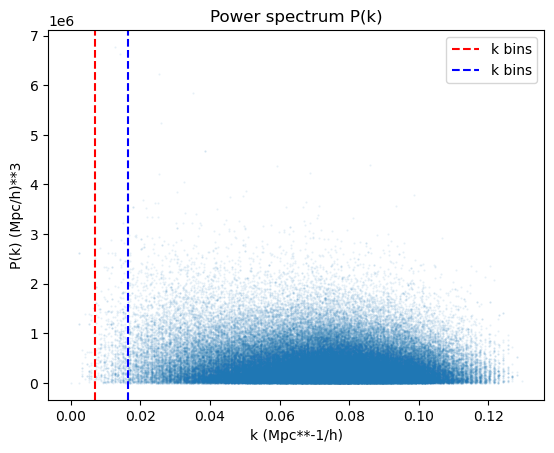

In [ ]:
# FFT del campo di densità normalizzato 
delta_k=rfftn(density_field)/n_cells**3   

# Calcolo le frequenze fondamentali e Nyquist
kF=2*np.pi/L   
H=L/n_cells
kN=np.pi/H   

# Creo gli array delle componenti di k
kx=fftfreq(n_cells,d=1/n_cells)*kF
ky=fftfreq(n_cells,d=1/n_cells)*kF
kz=rfftfreq(n_cells,d=1/n_cells)*kF 

KX,KY,KZ=np.meshgrid(kx,ky,kz)  # meshgrid per costruire il modulo di k su tutta la griglia
KK=np.sqrt(KX**2+KY**2+KZ**2) 

pk_grid=delta_k*np.conjugate(delta_k)*volume   # Spettro di potenza su griglia

# Creo i bin di k per mediare poi P(k)
c=1
k_edges=np.arange(kF,kN,c*kF) 
k_bins=0.5*(k_edges[1:]+k_edges[:-1])

plt.plot(KK.flatten(),pk_grid.flatten(),'.',markersize=1,alpha=0.1)  # Visualizzo distribuzione grezza P(k) su tutti i modi k
plt.axvline(k_edges[2], color='red', linestyle='--', label='k bins')  
plt.axvline(k_edges[6], color='blue', linestyle='--', label='k bins')
plt.xlabel('k (Mpc**-1/h)')
plt.ylabel('P(k) (Mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()

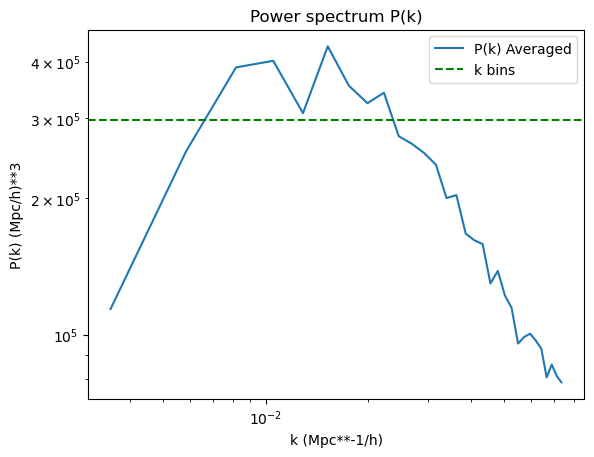

In [ ]:
pk_averaged=np.zeros(k_bins.shape)  # Inizializzo array per P(k) mediato
k_averaged=np.zeros(k_bins.shape)

# Media su gusci sferici in k-space
for i in range(len(k_bins)):
    mask=(KK.flatten()>k_edges[i]) & (KK.flatten()<k_edges[i+1])
    pk_averaged[i]=np.mean(pk_grid.flatten()[mask].real)
    k_averaged[i]=np.mean(KK.flatten()[mask])

# Visualizzo spettro mediato + shot noise
plt.loglog(k_bins,pk_averaged-1./density,label='P(k) Averaged') # Si sottrae il rumore di shot noise (1/density), cioè il contributo artificiale dovuto al fatto che stiamo usando un numero finito di oggetti discreti
plt.axhline(1./density, color='green', linestyle='--', label='k bins') # Serve come riferimento per vedere a che scale il rumore domina
plt.xlabel('k (Mpc**-1/h)')
plt.ylabel('P(k) (Mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()

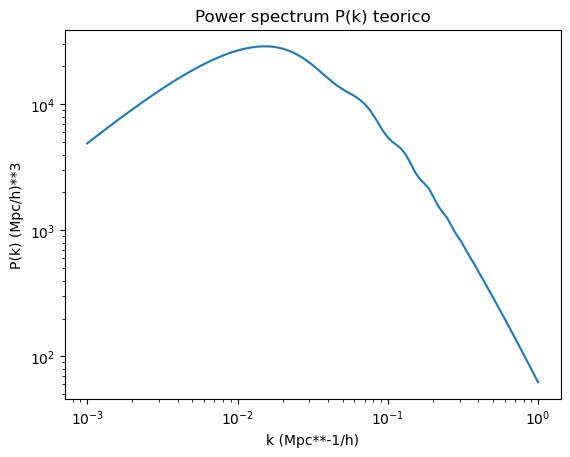

In [ ]:
# Calcolo spettro teorico con CAMB
import camb
camb_params=camb.CAMBparams()
h=0.704        #NB: H0 = 100 * h
ombh2=0.022
omega_m=0.272  #come ombch2 di un altro esercizio, ovvero ombh2+omch2
omch2=omega_m* h**2 -ombh2  # Ricavo omega_chi2

# Imposto cosmologia
camb_params.set_cosmology(H0=70.4,ombh2=0.022,omch2=omch2,mnu=0,num_massive_neutrinos=0)
camb_params.InitPower.set_params(ns=0.963)   # Imposta l’indice spettrale ns per la potenza primordiale
camb_params.set_matter_power(redshifts=[0.,],kmax=1.0)  # Voglio lo spettro di potenza a z=0 fino a k=1 (Mpc/h)^-1

# Ottengo i risultati
camb_results=camb.get_results(camb_params)
k,z,pk=camb_results.get_matter_power_spectrum(minkh=0.001,maxkh=1.0) # ottengo array di k ((Mpc/h)^-1), z (qui solo z=0) e pk non normaliz. ((Mpc/h)^3)
sigma8_z0=camb_results.get_sigma8_0()  # Ottengo sigma8 (varianza della densità a scala 8 Mpc/h) dal modello
pk_renorm=pk[0]*(0.809)**2/sigma8_z0**2 # Riscalo pk in modo che sigma8=0.809, ovvero quello della simulazione

plt.loglog(k,pk_renorm)  # Grafico dello spettro teorico calcolato
plt.xlabel('k (Mpc**-1/h)')
plt.ylabel('P(k) (Mpc/h)**3')
plt.title('Power spectrum P(k) teorico')
plt.show()

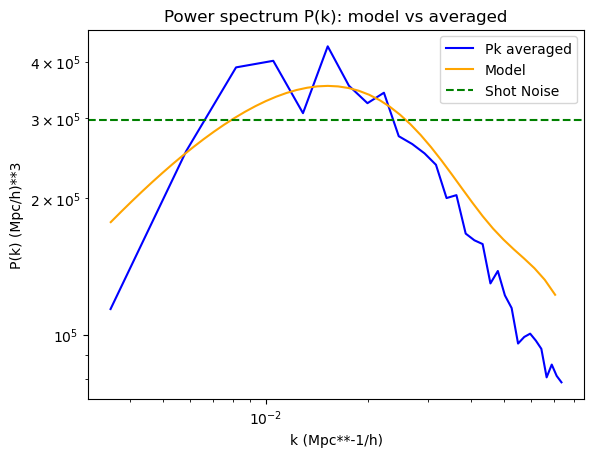

In [ ]:
# Confronto tra spettro numerico e teorico (con bias b)
b=3.5  # b rappresenta il fattore con cui la distribuzione delle galassie è "amplificata" rispetto alla distribuzione della materia
plt.loglog(k_bins,pk_averaged-1./density, label='Pk averaged', color='blue')  
plt.loglog(k[(k>k_bins[0]) &(k<k_bins[-1])],  # Seleziona intervallo comune tra modello e dati per confronto
           b**2*pk_renorm[(k>k_bins[0])&(k<k_bins[-1])], label='Model', color='orange')   # Spettro teorico scalato per b^2 :P_gal=P_matter*b**2
plt.axhline(1./density,linestyle='--',label='Shot Noise',color='green') 
plt.xlabel('k (Mpc**-1/h)')
plt.ylabel('P(k) (Mpc/h)**3')
plt.title('Power spectrum P(k): model vs averaged')
plt.legend()
plt.show()

NB: Il modello teorico (con bias) riproduce bene il comportamento osservato nelle simulazioni su scale intermedie, mentre agli estremi l’accordo peggiora per motivi noti: effetti non lineari (volume limitato) a piccole scale e rumore statistico a grandi scale.